<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Библиотека sklearn и классификация с помощью KNN</b></h1>

## Описание домашнего задания

В данном задании вы будете работать с датасетом о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Вам предстоит предсказать, кто из персонажей умрет, а кто останется вживых.



Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Represents whether the character is married

* **Is spouse alive**: Represents whether character's spouse is alive

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

Оценивание:

Баллы считаются следующим образом:

1) $1.00 \geqslant score \geqslant 0.75$ --- 5 баллов

2) $0.75 > score \geqslant 0.65$ --- 4 балла

3) $0.65 > score \geqslant 0.55$ --- 3 балла

4) $0.55 > score \geqslant 0.50$ --- 2 балла

5) $0.50 > score \geqslant 0.45$ --- 1 балл

6) $0.45 > score$ --- 0 баллов

## Часть 1. Анализ и предобработка данных

Здесь вам необходимо сделать все шаги, которые обсуждались в первой части семинара.
* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

Загружаем датасет

In [ ]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /content/game_of_thrones_test.csv
100% 37.3k/37.3k [00:00<00:00, 49.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /content/game_of_thrones_train.csv
100% 138k/138k [00:00<00:00, 20.0MB/s]


**Задание 1.1.** Импортируйте библиотеки pandas, matplotlib, seaborn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Задание 1.2.** Загрузите датасет в Pandas DataFrame при помощи функции `read_csv`. Вместо дефолтных наименований строк `0,1,...`, при помощи параметра `index_col`, сделайте значения колонки `S.No` наименованиями строк:

In [ ]:
data = pd.read_csv('/content/game_of_thrones_train.csv', index_col='S.No')
test = pd.read_csv('/content/game_of_thrones_test.csv', index_col='S.No')

In [ ]:
data.head()

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.267559,1
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,NaN,NaN,NaN,0.0,1,1,23.0,0,0.183946,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,NaN,NaN,NaN,1.0,1,1,29.0,0,0.043478,1


**Задание 1.3.** Предобработка (очистка) данных.

Проанализируйте, если в колонках NaN значения. Если есть, примите решение, как вы их будете обрабатывать. Вы можете либо удалить их, либо заполнить каким нибудь значением (например, медианой или модой).

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1557 non-null   object 
 1   title             717 non-null    object 
 2   male              1557 non-null   int64  
 3   culture           488 non-null    object 
 4   dateOfBirth       279 non-null    float64
 5   mother            18 non-null     object 
 6   father            22 non-null     object 
 7   heir              21 non-null     object 
 8   house             1176 non-null   object 
 9   spouse            200 non-null    object 
 10  book1             1557 non-null   int64  
 11  book2             1557 non-null   int64  
 12  book3             1557 non-null   int64  
 13  book4             1557 non-null   int64  
 14  book5             1557 non-null   int64  
 15  isAliveMother     18 non-null     float64
 16  isAliveFather     22 non-null     float64
 17  

In [ ]:
data.isAlive.value_counts()

,count
isAlive,
1,1212
0,345


In [ ]:
data.isnull().sum()

,0
name,0
title,840
male,0
culture,1069
dateOfBirth,1278
mother,1539
father,1535
heir,1536
house,381
spouse,1357


In [ ]:
#data = data.drop(columns=['father', 'mother', 'heir', 'spouse', 'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse'])
data = data.drop(columns=['father', 'mother', 'heir', 'spouse'])
data[['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse']] = data[['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse']].fillna(-1)

In [ ]:
title_values = data.title.value_counts()
title_values

,count
title,
Ser,306
Maester,29
Archmaester,21
Lord,19
Septon,16
...,...
Lord of Hellholt,1
Red Flower Vale,1
Lord of Harrenhal,1


In [ ]:
t_v = title_values.loc[title_values > 2].to_dict()

t_v # допустим, в словаре находятся интересующие меня титулы.
    # Если титула нет в этом словаре, то я поменяю его на "rare", если титул не известен, то пишу "unknown"

{'Ser': 306,
 'Maester': 29,
 'Archmaester': 21,
 'Lord': 19,
 'Septon': 16,
 'Winterfell': 15,
 'Lady': 10,
 'King in the North': 9,
 'Septa': 9,
 'Princess': 9,
 'Cupbearer': 8,
 "Lord Commander of the Night's Watch": 8,
 'Prince': 7,
 'Grand Maester': 6,
 'Khal': 5,
 'Wisdom': 5,
 'Prince of Dragonstone': 4,
 'King-Beyond-the-Wall': 4,
 'Queen': 3,
 'Last Hearth': 3,
 'Casterly Rock': 3,
 'Bitterbridge': 3,
 'Lord Paramount of the Mander': 3,
 'Eyrie': 3,
 'Lord of the Tides': 3,
 'Bloodrider': 3,
 'Brother': 3,
 'Duskendale': 3,
 'Starpike': 3,
 'Harrenhal': 3}

In [ ]:
data.title = data.title.fillna('Unknown')
data.title = data.title.apply(lambda x: 'Rare' if x not in t_v else x)

Я не знаю что еще хорошего придумать так что пустые значения для culture и house тоже заменю на unknown. Возраст заполню средним, др числовые признаки заполню -1.

In [ ]:
data["age"].fillna(data["age"].mean(), inplace=True)
data["culture"].fillna("Unknown", inplace=True)
data["dateOfBirth"].fillna(-1, inplace=True)
data["house"].fillna("Unknown", inplace=True)

/tmp/ipykernel_671/1936934501.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["age"].fillna(data["age"].mean(), inplace=True)
/tmp/ipykernel_671/1936934501.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1557 non-null   object 
 1   title             1557 non-null   object 
 2   male              1557 non-null   int64  
 3   culture           1557 non-null   object 
 4   dateOfBirth       1557 non-null   float64
 5   house             1557 non-null   object 
 6   book1             1557 non-null   int64  
 7   book2             1557 non-null   int64  
 8   book3             1557 non-null   int64  
 9   book4             1557 non-null   int64  
 10  book5             1557 non-null   int64  
 11  isAliveMother     1557 non-null   float64
 12  isAliveFather     1557 non-null   float64
 13  isAliveHeir       1557 non-null   float64
 14  isAliveSpouse     1557 non-null   float64
 15  isMarried         1557 non-null   int64  
 16  isNoble           1557 non-null   int64  
 17  

**Задание 1.4.** Создайте новые признаки.
* Создайте признак isPopular. У вас есть в таблице признак popularity score, поставьте какой то порог, например, 0.5, и пусть те персонажи, у которых popularity score меньше 0.5, непопулярны, т.е. isPopular = 0. Если же выше 0.5, тогда пусть isPopular=1.
* Создайте признак boolDeadRelations. Давайте упростим признак numDeadRelations, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. numDeadRelations > 0, и те, у которых не было, т.е. numDeadRelations = 0.
* Упростите признак culture, объединив схожие названия в один.


In [ ]:
data['isPopular'] = data.popularity.apply(lambda x: 0 if x < 0.5 else 1)
data = data.drop(columns=['popularity'])

In [ ]:
data['boolDeadRelations'] = data.numDeadRelations.apply(lambda x: 0 if x == 0 else 1)
data = data.drop(columns=['numDeadRelations'])

In [ ]:
def cult_pre(x):
  cult = {
    'Summer Islands': ['summer islands', 'summer islander', 'summer isles'],
    'Ghiscari': ['ghiscari', 'ghiscaricari',  'ghis'],
    'Asshai': ["asshai'i", 'asshai'],
    'Lysene': ['lysene', 'lyseni'],
    'Andal': ['andal', 'andals'],
    'Braavosi': ['braavosi', 'braavos'],
    'Dornish': ['dornishmen', 'dorne', 'dornish'],
    'Myrish': ['myr', 'myrish', 'myrmen'],
    'Westermen': ['westermen', 'westerman', 'westerlands'],
    'Westerosi': ['westeros', 'westerosi'],
    'Stormlander': ['stormlands', 'stormlander'],
    'Norvoshi': ['norvos', 'norvoshi'],
    'Northmen': ['the north', 'northmen'],
    'Free Folk': ['wildling', 'first men', 'free folk'],
    'Qartheen': ['qartheen', 'qarth'],
    'Reach': ['the reach', 'reach', 'reachmen'],
    'Ironborn': ['ironborn', 'ironmen'],
    'Mereen': ['meereen', 'meereenese'],
    'RiverLands': ['riverlands', 'rivermen'],
    'Vale': ['vale', 'valemen', 'vale mountain clans']}

  for i in cult:
    if x.lower() in cult[i]:
      return i
  return x

In [ ]:
data['culture'] = data.culture.apply(cult_pre)

**Задание 1.5.** Проанализируйте, какие столбцы являются существенными и влияют на предсказание, а какие нет. Удалите ненужные столбцы по вашему мнению.

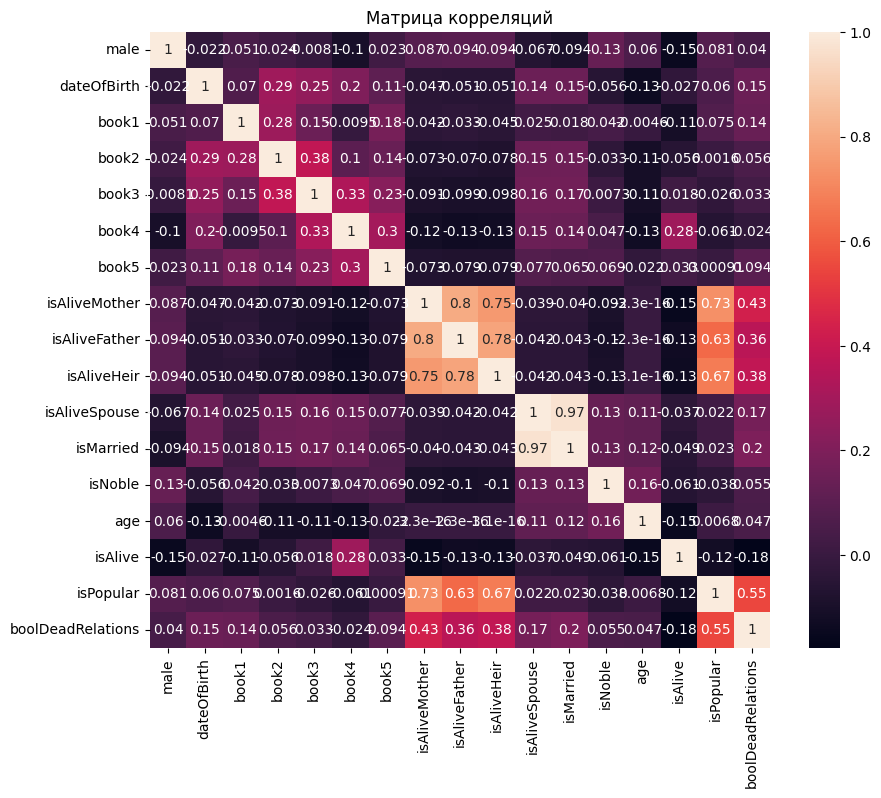

In [ ]:
corr = data.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True)
plt.title('Матрица корреляций')
plt.show()

In [ ]:
data = data.drop(columns='name')

**Задание 1.6.** Проанализируйте целевую переменную. Посмотрите, является ли она категориальной или количественной. Так как мы говорим о задаче классификации, проанализируйте является ли датасет сбалансированным по классам или нет.

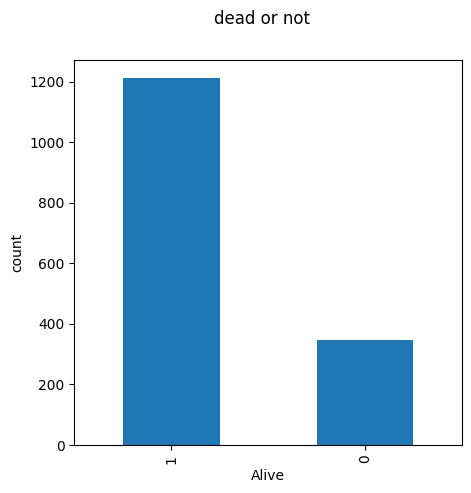

In [ ]:
plt.figure(figsize = (5, 5))

data['isAlive'].value_counts().plot.bar()
plt.ylabel('count')
plt.xlabel('Alive')

plt.suptitle('dead or not')
plt.show()

Целевая переенная является категориальной. Датасет несбалансирован

**Задание 1.7.** Проанализируйте признаки.
  * Обработайте категориальные признаки и переведите их в числа. Можете выбрать любой кодировщик.
  * Проанализируйте количественные признаки. Есть ли корреляция между признаками?

In [ ]:
categorical_features = data[['title', 'culture', 'house']]

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(categorical_features)

#Create a DataFrame with the one-hot encoded columns
#We use get_feature_names_out() to get the column names for the encoded data
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(['title', 'culture', 'house']), index=data.index
                          )

In [ ]:
one_hot_df

,title_Archmaester,title_Bitterbridge,title_Bloodrider,title_Brother,title_Casterly Rock,title_Cupbearer,title_Duskendale,title_Eyrie,title_Grand Maester,title_Harrenhal,...,house_Sea watch,house_Second Sons,house_Stone Crows,house_Stormcrows,house_Summer Islands,house_The Citadel,house_Unknown,house_Windblown,house_Wise Masters,house_wildling
S.No,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1554,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1555,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Concatenate the one-hot encoded dataframe with the original dataframe
df_encoded = pd.concat([data, one_hot_df], axis=1)

# Drop the original categorical columns
df_encoded = df_encoded.drop(['title', 'culture', 'house'], axis=1)

# Display the resulting dataframe
df_encoded

,male,dateOfBirth,book1,book2,book3,book4,book5,isAliveMother,isAliveFather,isAliveHeir,...,house_Sea watch,house_Second Sons,house_Stone Crows,house_Stormcrows,house_Summer Islands,house_The Citadel,house_Unknown,house_Windblown,house_Wise Masters,house_wildling
S.No,,,,,,,,,,,,,,,,,,,,,
1,1,-1.0,0,0,0,0,0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1,208.0,1,1,1,1,1,-1.0,-1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,-1.0,0,0,0,1,0,-1.0,-1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,82.0,0,0,0,0,0,-1.0,-1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0,276.0,0,0,0,1,0,-1.0,-1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,1,-1.0,1,0,1,1,0,-1.0,-1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1554,0,-1.0,1,1,0,0,0,-1.0,-1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1555,1,-1.0,0,1,1,1,1,-1.0,-1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


А теперь я сделаю аналогичную предобработку для test

In [ ]:
test.title = test.title.fillna('Unknown')
test.title = test.title.apply(lambda x: 'Rare' if x not in t_v else x)
test.culture = test.culture.fillna('Unknown')
test.house = test.house.fillna('Unknown')
test.age = test.age.fillna(data["age"].mean())
test.dateOfBirth = test.dateOfBirth.fillna(-1)
test['isPopular'] = test.popularity.apply(lambda x: 0 if x < 0.5 else 1)
test = test.drop(columns=['popularity'])
test['boolDeadRelations'] = test.numDeadRelations.apply(lambda x: 0 if x == 0 else 1)
test = test.drop(columns=['numDeadRelations'])
test['culture'] = test.culture.apply(cult_pre)
test = test.drop(columns='name')
test[['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse']] = test[['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse']].fillna(-1)
test = test.drop(columns=['father', 'mother', 'heir', 'spouse'])

In [ ]:
categorical_features_test = test[['title', 'culture', 'house']]
one_hot_encoded = encoder.fit_transform(categorical_features_test)

one_hot_test = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(['title', 'culture', 'house']), index=test.index)

# Concatenate the one-hot encoded dataframe with the original dataframe
test_encoded = pd.concat([test, one_hot_test], axis=1)

# Drop the original categorical columns
test_encoded = test_encoded.drop(['title', 'culture', 'house'], axis=1)

In [ ]:
# перегоняю признаки из одного датафрейма в другой, чтоб и в тесте и в трейне был одинаковый набор признаков.
df_encoded, test_encoded = df_encoded.align(test_encoded, join='left', axis=1, fill_value=0)
test_encoded = test_encoded.drop(columns=['isAlive'])

**Задание 1.8.** Проанализируйте влияние признаков на целевую переменную.

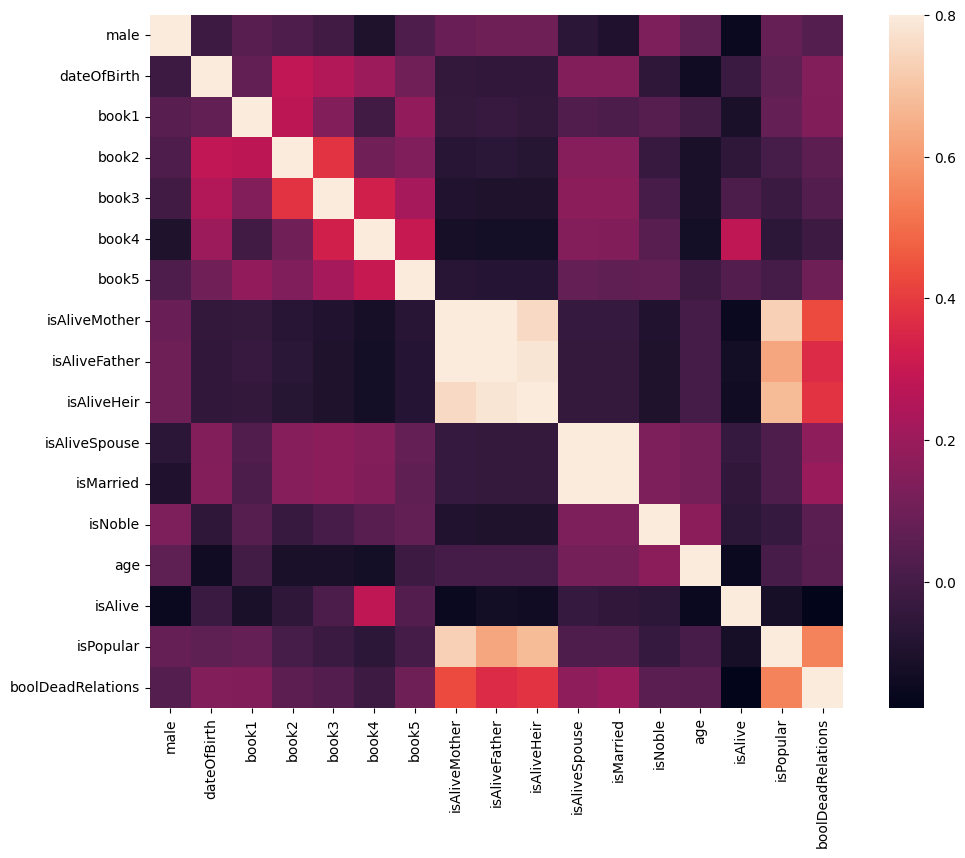

In [ ]:
corrmat = data.drop(columns=['title', 'culture', 'house']).corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True);

**Задание 1.9.** Создайте переменные `X`, которая будет хранить только значения признаков, и `y`, которая будет хранить только значения целевой переменной.

In [ ]:
X = df_encoded.drop(columns='isAlive').values
y = df_encoded.isAlive.values

**Задание 1.10.** Разделите датасет на train и test часть при помощи функции `train_test_split`

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

## Часть 2. Обучение моделей

В данной части домашнего задания, мы хотим научиться обучать модели для задачи классификации на наших данных.

**Задание 2.1.** Импортируйте следующие модели из библиотеки `sklearn`
* LogisticRegression
* RandomForestClassifier
* AdaBoostClassifier
* GaussianProcessClassifier
* GaussianNB
* KNeighborsClassifier
* SVC
* DecisionTreeClassifier


В качестве примера, импортируем модель `LogisticRegression`

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, r2_score

Импортируйте остальные модели из библиотеки `sklearn`. Чтобы понять как это сделать, воспользуйтесь официальный документацией `sklearn` $→$ [тык](https://scikit-learn.org/dev/user_guide.html). По ключевому названию модели, вы сможете найти необходимую информацию о том, как можно импортировать модель из библиотеки.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [ ]:
from sklearn.metrics import accuracy_score

**Задание 2.2.** Обучите модель и сделайте предсказание на тестовой выборке

В качестве примера, обучим модель `LogisticRegression` и сделаем на ней предсказания на тестовой выборке.

In [ ]:
# Шаг 1. создание модели
logistic_regression = LogisticRegression(solver='lbfgs', max_iter=40000)
param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
gridsearch = GridSearchCV(logistic_regression, param_grid, refit=True, scoring=make_scorer(r2_score))

# Шаг 2. обучение модели
gridsearch.fit(X_train, y_train)

# выведем наилучшие параметры
print(gridsearch.best_params_)

{'C': 0.1}


In [ ]:
# Шаг 1. создание модели
logistic_regression = LogisticRegression(C=0.1, solver='lbfgs', max_iter=40000)

# Шаг 2. обучение модели
logistic_regression.fit(X_train, y_train)

# Шаг 3. Предсказание на тестовых данных
y_pred = logistic_regression.predict(X_test)

In [ ]:
# Шаг 4. Оценка предсказания по метрике accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy : %.4f" % accuracy)

Accuracy : 0.8013


Аналогичным образом обучите остальные модели и сделайте предсказания на тестовой выборке.

In [ ]:
models = {
    "LogisticRegression": (
        LogisticRegression(max_iter=10000),
        {"C": [0.1]}),

    "RandomForest": (
        RandomForestClassifier(),
        {"n_estimators": [100, 200],
         "max_depth": [None, 10, 20]}),

    "AdaBoost": (
        AdaBoostClassifier(),
        {"n_estimators": [50, 100],
         "learning_rate": [0.5, 1.0]}),

    "GaussianProcess": (
        GaussianProcessClassifier(),
        {}),

    "GaussianNB": (
        GaussianNB(),
        {}),

    "KNN": (
        KNeighborsClassifier(),
        {"n_neighbors": [3, 5, 7]}),

    "SVC": (
        SVC(),
        {
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf"]
        }
    ),

    "DecisionTree": (
        DecisionTreeClassifier(),
        {"max_depth": [None, 10, 20]})
}

In [ ]:
results = {}

for name, (model, params) in models.items():
    print(f"Обучаем {name}...")

    grid = GridSearchCV(
        model,
        params,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    results[name] = {
        "best_score": grid.best_score_,
        "best_params": grid.best_params_
    }

Обучаем LogisticRegression...
Обучаем RandomForest...
Обучаем AdaBoost...
Обучаем GaussianProcess...
Обучаем GaussianNB...
Обучаем KNN...
Обучаем SVC...
Обучаем DecisionTree...


In [ ]:
for name, res in results.items():
    print(name)
    print("Score:", res["best_score"])
    print("Params:", res["best_params"])
    print()

LogisticRegression
Score: 0.8056224899598394
Params: {'C': 0.1}

RandomForest
Score: 0.8152610441767069
Params: {'max_depth': 20, 'n_estimators': 200}

AdaBoost
Score: 0.8072289156626506
Params: {'learning_rate': 1.0, 'n_estimators': 100}

GaussianProcess
Score: 0.8425702811244979
Params: {}

GaussianNB
Score: 0.43052208835341366
Params: {}

KNN
Score: 0.823293172690763
Params: {'n_neighbors': 7}

SVC
Score: 0.8176706827309237
Params: {'C': 10, 'kernel': 'rbf'}

DecisionTree
Score: 0.7951807228915664
Params: {'max_depth': 20}



## Часть 3. Оцените качество моделей

Вам необходимо познакомиться с метриками задачи классификации из sklearn. Оцените все модели и выберите лучшую по метрике качества Accuracy.

С метриками классификации вы можете ознакомиться в [Yandex ML Book](https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii).

Для простоты в данном домашнем задании мы будем работать с самой базовой метрикой для задачи классификации - accuracy.

**Задание 3.1.** Вам необходимо посчитать метрику для всех моделей и выбрать лучшую модель.

Сначала импортируем необходимую функцию из библиотеки sklearn для подсчета accuracy.

In [ ]:
# сделала в предыдущем пункте параллельно с обучением модели

Аналогичным образом посчитайте метрику accuracy для остальных моделей

Выберите лучшую модель.

In [ ]:
best_model = max(results, key=lambda x: results[x]['best_score'])
print("Лучшая модель:", best_model)

Лучшая модель: GaussianProcess


### Файл `submission.csv`

Вам нужно вместо значений в `submission.csv` файле в колонке `isAlive`, подставить свои предсказания и сохранить измененный файл.

In [ ]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /content/submission.csv
100% 2.74k/2.74k [00:00<00:00, 9.14MB/s]


In [ ]:
submission = pd.read_csv("/content/submission.csv", index_col='S.No')

In [ ]:
# Шаг 1. создание модели
GaussianProcess = GaussianProcessClassifier()

# Шаг 2. обучение модели
GaussianProcess.fit(X_train, y_train)

# Шаг 3. Предсказание на тестовых данных
y_fin_pred = GaussianProcess.predict(test_encoded)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GaussianProcessClassifier was fitted without feature names
  warnings.warn(


In [ ]:
submission.isAlive = y_fin_pred

In [ ]:
submission

,isAlive
S.No,
1558,0
1559,1
1560,1
1561,1
1562,0
...,...
1942,1
1943,1
1944,1


In [ ]:
submission.value_counts()

,count
isAlive,
1,323
0,66


In [ ]:
submission = submission.reset_index()

Как сохранить измененный Pandas DataFrame в csv файл:

In [ ]:
submission.to_csv("/content/new_submission.csv", index=False)